# Tech Salary Analysis - Section 1: EDA

## Phase 1: Data Health, Cleaning, Manipulating, Preparing

### 1.1 Importing Libraries and Loading Data

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy as sp
import os
from dotenv import load_dotenv
import warnings

warnings.filterwarnings('ignore')
load_dotenv()
print('libraries imported!')

libraries imported!


In [2]:
# Load the dataset

file_path = os.getenv('CSV_2_PATH')
df = pd.read_csv(file_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 50)


,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,EMP-00001,Emma,Johansson,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,...,417.44,5175.31,62103.72,6271.69,3,12.9,38,1,6,False
1,EMP-00002,Stephanie,Zhang,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,...,504.87,10082.84,120994.08,10151.16,4,6.5,26,1,4,False
2,EMP-00003,Raj,Lopez,32,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,...,377.88,8111.78,97341.36,4172.42,5,13.2,0,0,6,True
3,EMP-00004,Amelia,Taylor,31,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,...,1140.39,23327.47,279929.64,19102.74,2,5.9,111,5,7,False
4,EMP-00005,Sophia,Gonzalez,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,...,844.73,11148.58,133782.96,3308.59,6,0.0,20,3,9,False


### 1.2 Initial Data Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  10000 non-null  str    
 1   first_name                   10000 non-null  str    
 2   last_name                    10000 non-null  str    
 3   age                          10000 non-null  int64  
 4   gender                       10000 non-null  str    
 5   location                     10000 non-null  str    
 6   currency                     10000 non-null  str    
 7   primary_tech_field           10000 non-null  str    
 8   job_title                    10000 non-null  str    
 9   employment_type              10000 non-null  str    
 10  work_arrangement             10000 non-null  str    
 11  experience_years_total       10000 non-null  float64
 12  experience_years_in_field    10000 non-null  float64
 13  education_level             

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,10000.0,31.637600,6.856892,18.00,27.0000,32.000,36.0000,58.00
experience_years_total,10000.0,5.717070,3.689415,0.50,2.8000,5.500,8.2000,19.60
experience_years_in_field,10000.0,4.019440,2.823968,0.50,1.8000,3.600,5.7000,17.80
num_skills,10000.0,5.494200,1.716176,3.00,4.0000,5.000,7.0000,8.00
annual_salary_usd,10000.0,171786.241744,72550.937998,19846.27,121355.0450,167055.180,216939.8675,479033.82
monthly_salary_usd,10000.0,14315.520181,6045.911530,1653.86,10112.9250,13921.265,18078.3250,39919.49
hourly_rate_usd,10000.0,91.601258,45.335040,9.54,61.1900,85.295,113.7700,373.06
annual_bonus_usd,10000.0,12363.473986,10863.881829,0.00,2282.8000,11302.280,18781.7875,81019.78
bonus_percentage,10000.0,7.214300,5.159558,0.00,5.0000,8.000,10.0000,20.00
equity_total_value_usd,10000.0,28710.888600,100995.443620,0.00,0.0000,0.000,9773.0000,995997.00


### 1.3 Checking for Missing Values & Duplicates

In [5]:
print('Duplicates:', df.duplicated().sum())
print('\nMissing Values:\n', df.isnull().sum()[df.isnull().sum() > 0])

Duplicates: 0

Missing Values:
 certifications    4508
dtype: int64


### 1.4 Data Cleaning & Imputation
Notice that ONLY `certifications` has missing values (4508 missing). We will fill these with 'No Certification'.

In [6]:
df['certifications'] = df['certifications'].fillna('No Certification')
print('Missing values after cleaning:', df.isnull().sum().sum())

Missing values after cleaning: 0


### 1.5 Data Type Optimization
Converting text columns to categorical to save memory.

In [7]:
cat_columns = ['gender', 'job_title','location', 'currency', 'primary_tech_field', 'employment_type', 'work_arrangement', 'education_level', 'company_size']
for col in cat_columns:
    df[col] = df[col].astype('category')

print('all cat columns has "Gategory" as dtype!')
df.info()

all cat columns has "Gategory" as dtype!
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   employee_id                  10000 non-null  str     
 1   first_name                   10000 non-null  str     
 2   last_name                    10000 non-null  str     
 3   age                          10000 non-null  int64   
 4   gender                       10000 non-null  category
 5   location                     10000 non-null  category
 6   currency                     10000 non-null  category
 7   primary_tech_field           10000 non-null  category
 8   job_title                    10000 non-null  category
 9   employment_type              10000 non-null  category
 10  work_arrangement             10000 non-null  category
 11  experience_years_total       10000 non-null  float64 
 12  experience_years_in_field    10

### 1.6 Variable Categorization (Discrete, Continuous, Categorical)

In [8]:
discrete_variables = []
continuous_variables = []
categorical_variables = []
boolean_variables = []

for var in df.columns :
    #variables
    col = df[var]
    unique_values = col.unique().tolist()
    distinct = len(unique_values)

    #conditions
    is_decimal = (col.dtype == 'float64')
    is_int = (col.dtype == 'int64')
    is_string = (col.dtype in ['str','category'])
    is_bool = (col.dtype == 'bool')
    if is_int or is_decimal :
        fractional_part_not_null = ((col.dropna() % 1 != 0).any())
        fractional_part_is_null = ((col.dropna() % 1 == 0).all())

    #logic
    if is_string :
        categorical_variables.append(var)

    elif (is_int or (is_decimal and fractional_part_is_null)) and (distinct < 10):
        discrete_variables.append(var)

    elif ((is_int or (is_decimal and fractional_part_is_null)) and distinct >= 10) or (is_decimal and fractional_part_not_null):
        continuous_variables.append(var)
    
    elif is_bool :
        boolean_variables.append(var)
    else:
        print(var, "is unknown")
categories = ['discrete', 'continuous', 'categorical', 'boolean']
for cat in categories :
    liste = globals()[f'{cat}_variables']
    if len(liste) == 0 :
        print(f'There is no {cat.capitalize()} variables in this dataframe')
    else : 
        print(f"{cat.capitalize()} variables :\n{liste}\n")


Discrete variables :
['num_skills', 'bonus_percentage', 'equity_vesting_years', 'vacation_weeks']

Continuous variables :
['age', 'experience_years_total', 'experience_years_in_field', 'annual_salary_usd', 'monthly_salary_usd', 'hourly_rate_usd', 'annual_bonus_usd', 'equity_total_value_usd', 'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd', 'monthly_net_salary_usd', 'monthly_housing_usd', 'monthly_transportation_usd', 'monthly_food_usd', 'monthly_utilities_usd', 'monthly_healthcare_usd', 'monthly_entertainment_usd', 'monthly_education_loan_usd', 'monthly_childcare_usd', 'monthly_miscellaneous_usd', 'monthly_total_expenses_usd', 'annual_total_expenses_usd', 'annual_savings_usd', 'overtime_hours_per_month', 'months_since_last_promotion', 'num_previous_companies', 'job_satisfaction_score']

Categorical variables :
['employee_id', 'first_name', 'last_name', 'gender', 'location', 'currency', 'primary_tech_field', 'job_title', 'employment_type', 'work_arrangement', 'educat

In [9]:
unique_dict = {} 
exclude_cols = ['employee_id', 'first_name', 'last_name']

for col in df.columns:
    
    is_string = (df[col].dtype in ['str','category'])
    
    if is_string and col not in exclude_cols:
        unique_values = df[col].unique().tolist()
        unique_values.sort()
        unique_dict[col] = unique_values
        print(f'For column "{col.upper()}" unique values are:\n{unique_dict[col]}\n')

For column "GENDER" unique values are:
['Female', 'Male', 'Prefer not to say']

For column "LOCATION" unique values are:
['Amsterdam, Netherlands', 'Austin, USA', 'Bangalore, India', 'Berlin, Germany', 'Boston, USA', 'Denver, USA', 'Hyderabad, India', 'London, UK', 'Miami, USA', 'New York, USA', 'Remote (Global)', 'San Francisco, USA', 'Seattle, USA', 'Seoul, South Korea', 'Singapore', 'Sydney, Australia', 'Tel Aviv, Israel', 'Tokyo, Japan', 'Toronto, Canada']

For column "CURRENCY" unique values are:
['AUD', 'CAD', 'EUR', 'GBP', 'ILS', 'INR', 'JPY', 'KRW', 'SGD', 'USD']

For column "PRIMARY_TECH_FIELD" unique values are:
['Backend Development', 'Blockchain & Web3', 'Cybersecurity', 'Data Science & ML', 'Database & Data Engineering', 'DevOps & Cloud', 'Embedded Systems & IoT', 'Frontend Development', 'Full-Stack Development', 'Game Development', 'Mobile Development', 'Product Management', 'QA & Testing', 'Site Reliability Engineering']

For column "JOB_TITLE" unique values are:
['AI Re

## Phase 2: Visualizing Data using Seaborn and Matplotlib

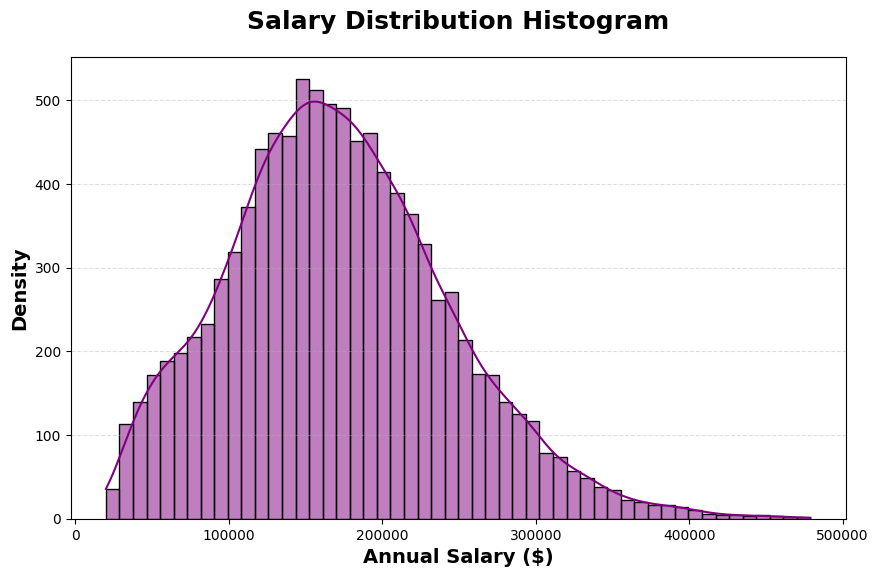

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, 
             x='annual_salary_usd',
             kde=True,
             color='purple')

plt.title('Salary Distribution Histogram', 
          fontsize=18, 
          fontweight='semibold',
          pad= 20)       
plt.xlabel('Annual Salary ($)', 
           fontsize=14, 
           fontweight='semibold')
plt.ylabel('Density', 
           fontsize=14, 
           fontweight='semibold')
plt.grid(True, 
         axis='y', 
         linestyle='--', 
         alpha=0.4)
plt.show()

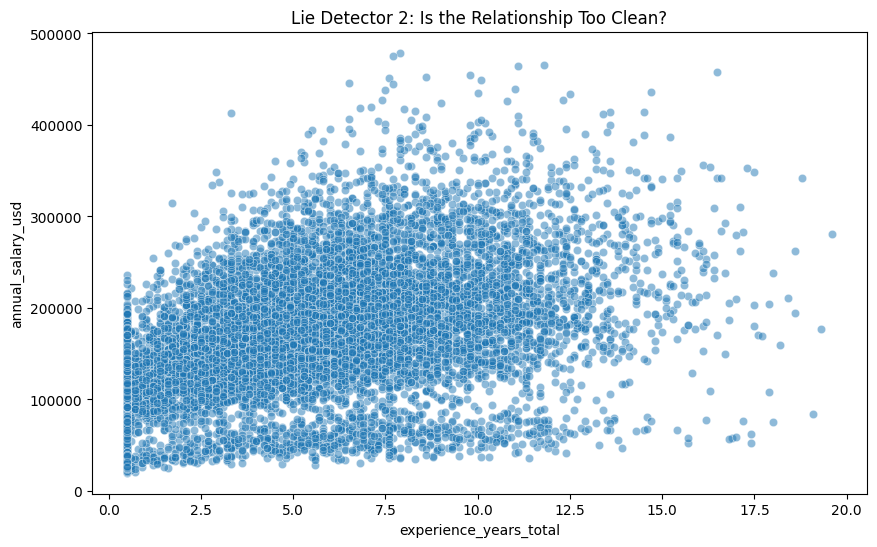

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(data=df,
                x='experience_years_total',
                y='annual_salary_usd',
                alpha=0.5,
                color='purple',
                s=80,                    
                edgecolor='white',
                linewidth=0.5)

plt.title('Experience vs Salary Relationship', 
          fontsize=20, 
          fontweight='bold',
          pad=20)
plt.xlabel('Total Experience (Years)', 
           fontsize=14, 
           fontweight='semibold')
plt.ylabel('Annual Salary ($)', 
           fontsize=14, 
           fontweight='semibold')

plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

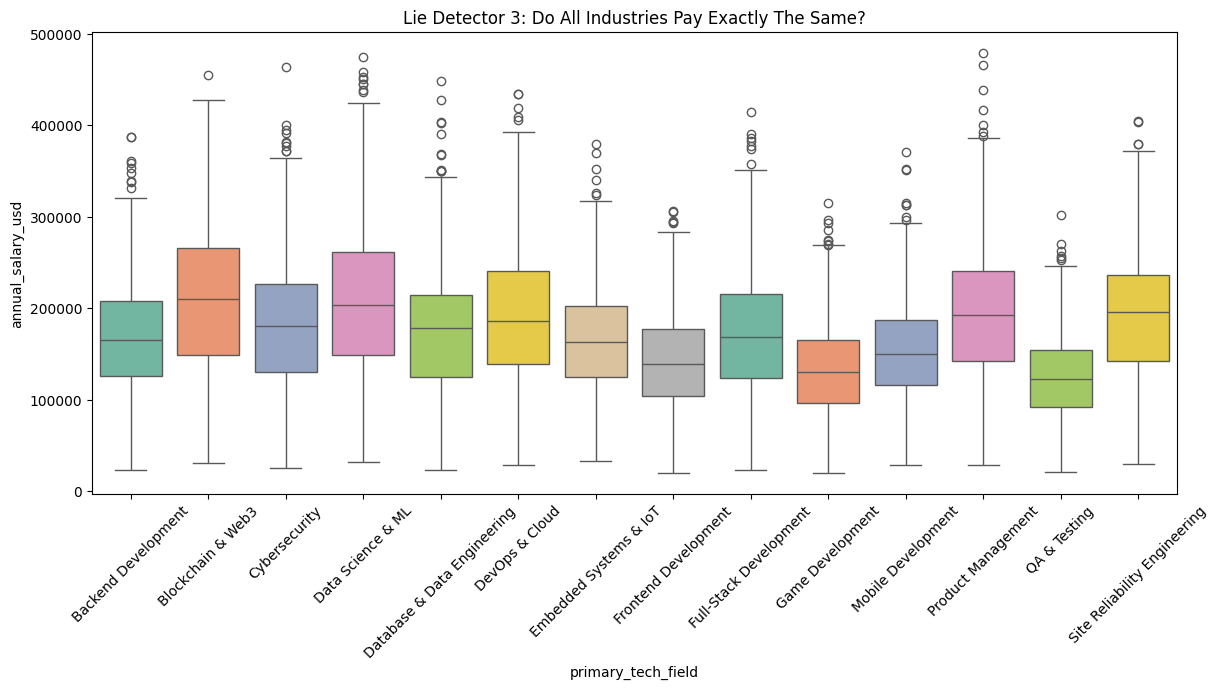

In [12]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='primary_tech_field', y='annual_salary_usd', palette='Set2')
plt.xticks(rotation=45)
plt.title('Lie Detector 3: Do All Industries Pay Exactly The Same?')
plt.show()


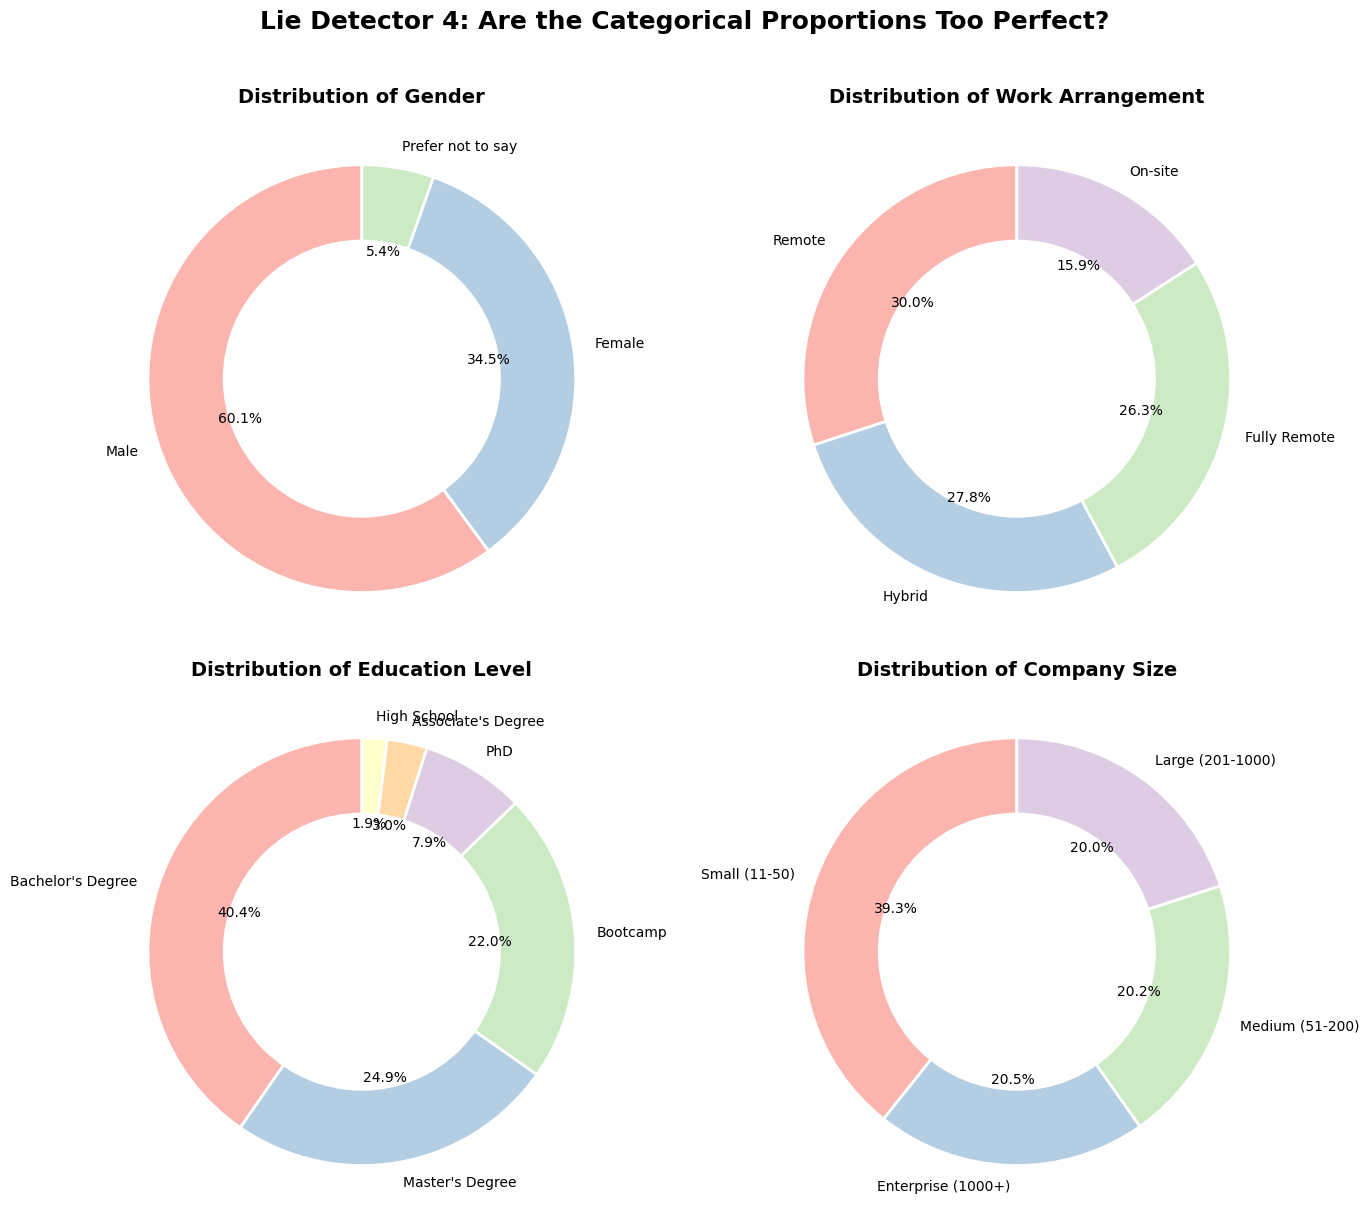

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. The 4 categorical columns we want to test
categories = ['gender', 'work_arrangement', 'education_level', 'company_size']

# 2. Set up a 2x2 grid for the charts
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# 3. Loop through and create a Donut Chart for each
for i, cat in enumerate(categories):
    # Count how many employees are in each category
    counts = df[cat].value_counts()
    
    # Draw the Pie Chart
    axes[i].pie(counts.values, 
                labels=counts.index, 
                autopct='%1.1f%%',         # Show the percentages
                startangle=90,             # Rotate so it looks nice
                colors=sns.color_palette('Pastel1'), 
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}) # Add white borders
    
    # Turn the Pie Chart into a Donut Chart by drawing a white circle in the middle!
    center_circle = plt.Circle((0, 0), 0.65, fc='white')
    axes[i].add_artist(center_circle)
    
    # Formatting
    axes[i].set_title(f'Distribution of {cat.replace("_", " ").title()}', fontsize=14, fontweight='bold')

plt.suptitle('Lie Detector 4: Are the Categorical Proportions Too Perfect?', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
